In [7]:
import json
from pathlib import Path

import pandas as pd

from src.utils import format_columnName, get_necessary_folders


evaluations = {
    (dim, Path(folder).name): json.load(
        (Path(folder) / dim / "results" / "evaluations.json").open()
    )
    for folder in get_necessary_folders()
    for dim in ["timeliness", "completeness", "consistency"]
    if (Path(folder) / dim / "results" / "evaluations.json").exists()
}

df = pd.DataFrame(
    [
        {
            "dimension": dim,
            "folder": folder,
            "metric": metric,
            "dataset": dataset.split(".")[0],
            "type": dataset.split(".")[1] if "." in dataset else "unknown",
            "column": format_columnName(column),
            "null_rate": results["dq_results_stats"]["null_rates"][column],
            "dq_results_mean": results["dq_results_stats"]["describe"][column]["mean"],
            "pollution_rate": results["pollution_rates"][column],
            "mse_dq": results["mse_per_column"]["With quality values"][column],
            "mse_dq_certainty": results["mse_per_column"]["With certainty weighting"][
                column
            ],
            "precision": results["pr_auc_per_column"][column]["precision"],
            "recall": results["pr_auc_per_column"][column]["recall"],
            "pr_auc": results["pr_auc_per_column"][column]["pr_auc"],
            "precision_weighted": results["pr_auc_per_column_weighted"][column][
                "precision"
            ],
            "recall_weighted": results["pr_auc_per_column_weighted"][column]["recall"],
            "pr_auc_weighted": results["pr_auc_per_column_weighted"][column]["pr_auc"],
            "kl_divergence": {
                agg_method: {
                    "gaussian": results["aggregation_evaluation"]["kl_divergence"][
                        agg_method
                    ]["kl_gaussian"][column],
                    "laplace": results["aggregation_evaluation"]["kl_divergence"][
                        agg_method
                    ]["kl_laplace"][column],
                    "exponential": results["aggregation_evaluation"]["kl_divergence"][
                        agg_method
                    ]["kl_exponential"][column],
                }
                for agg_method in results["aggregation_evaluation"][
                    "kl_divergence"
                ].keys()
            },
        }
        for (dim, folder), evaluation in evaluations.items()
        for metric, datasets in evaluation.items()
        for dataset, results in datasets.items()
        for column in results["dq_results_stats"]["describe"].keys()
    ]
)

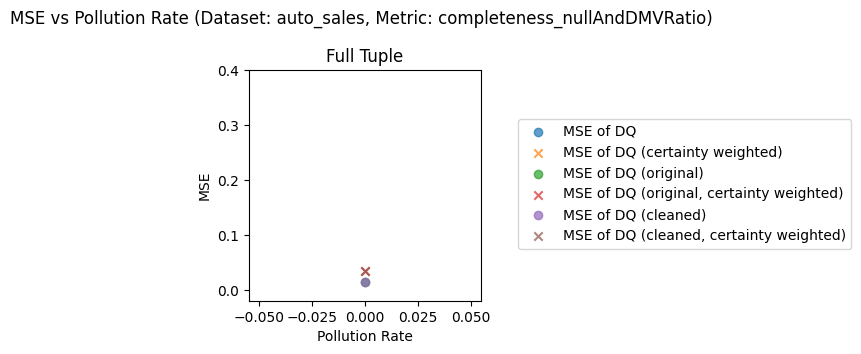

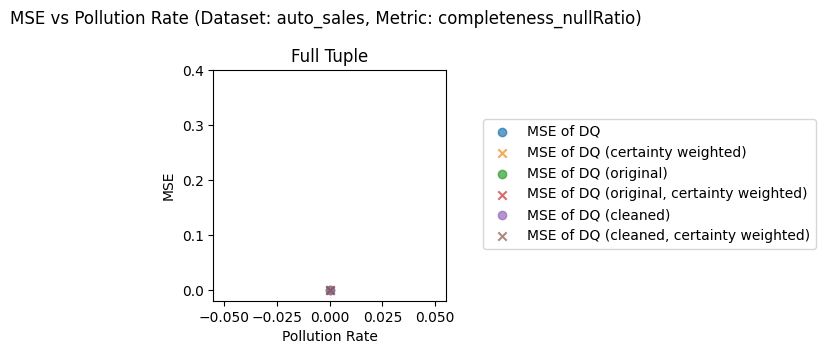

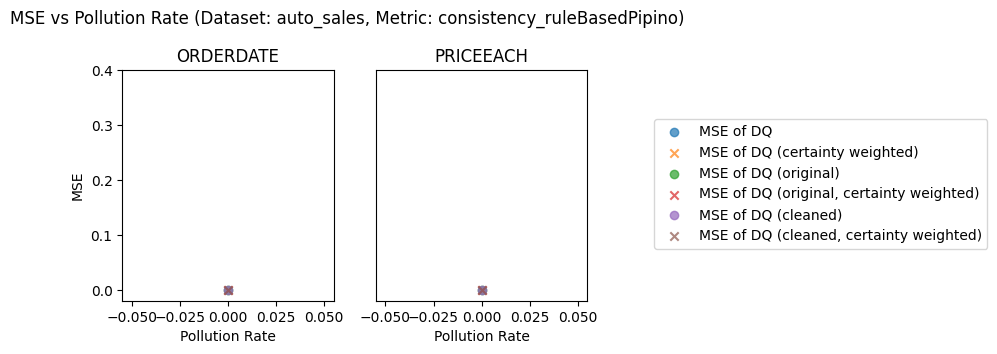

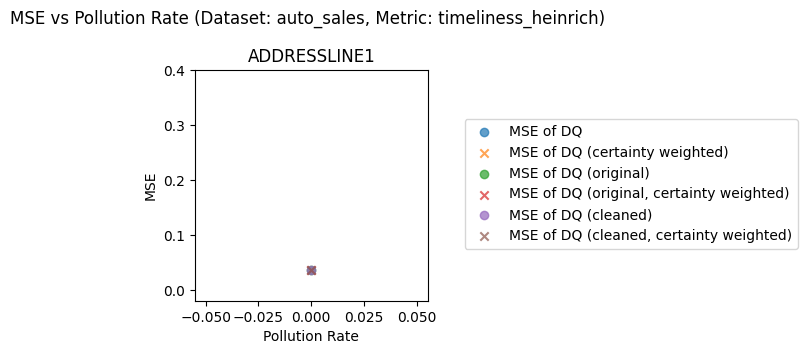

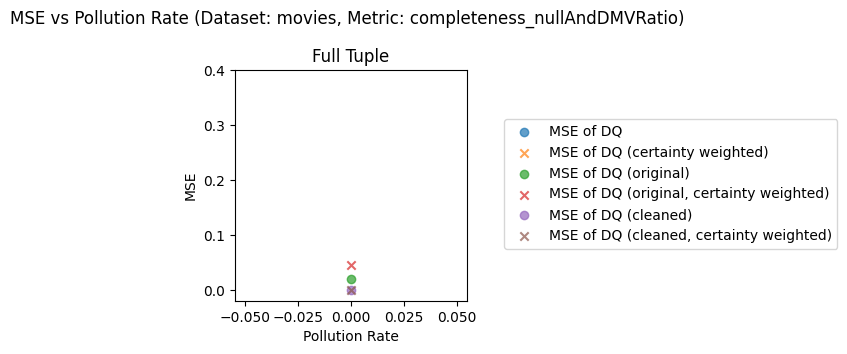

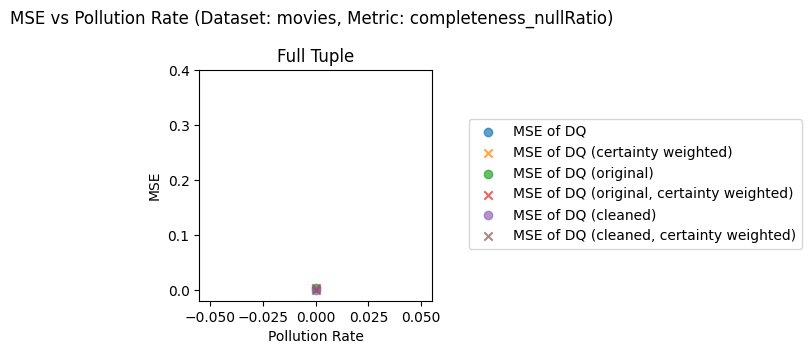

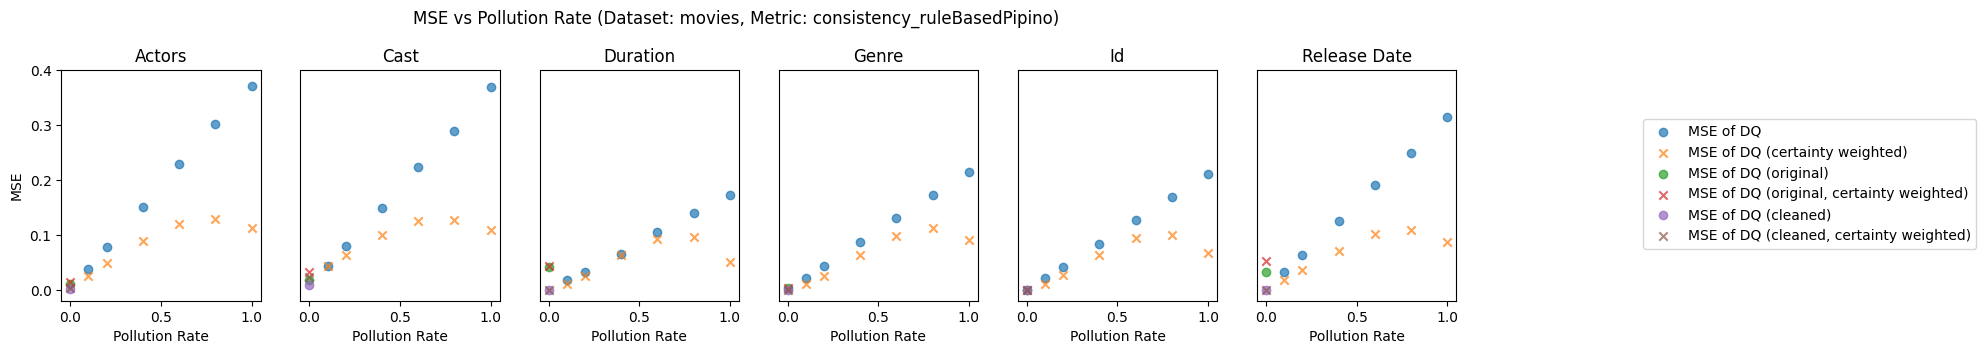

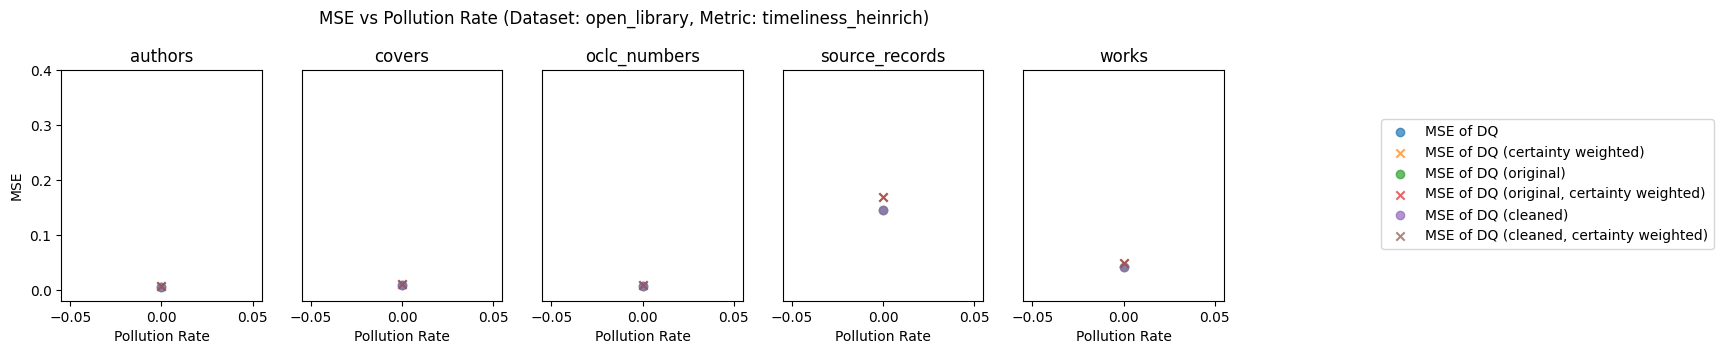

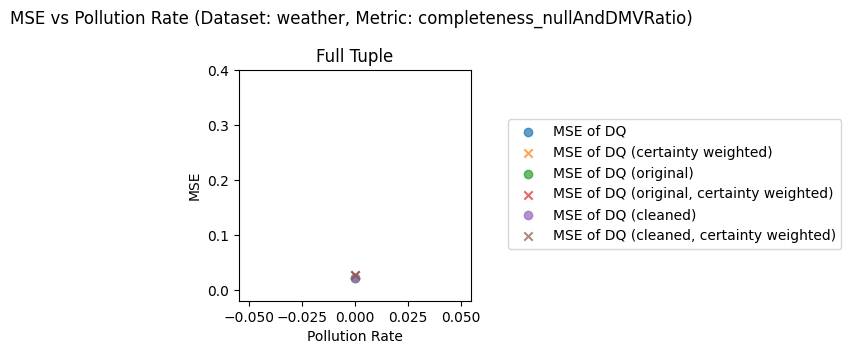

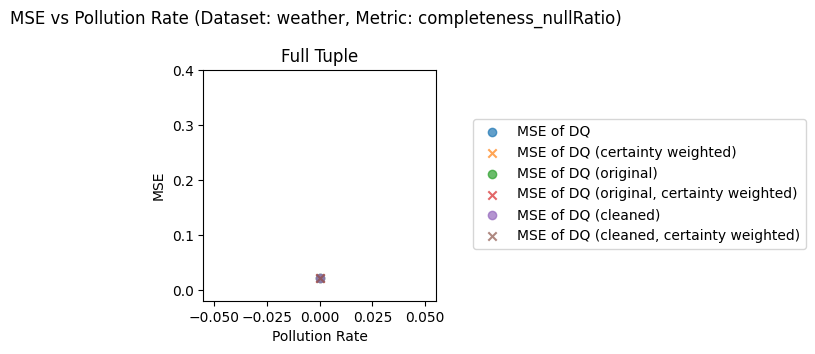

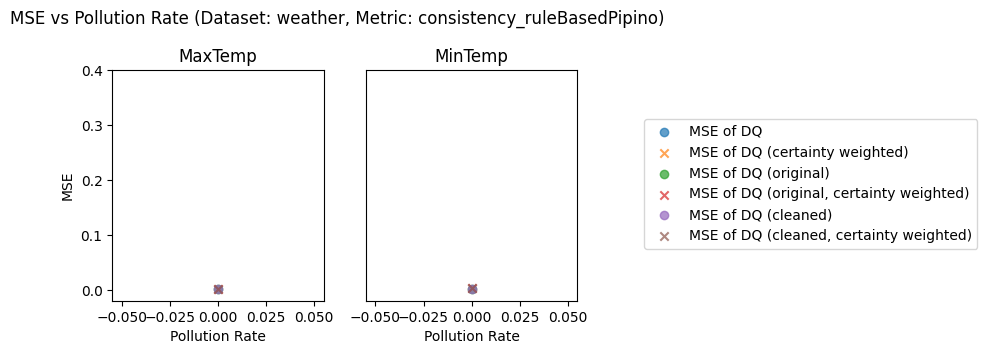

In [6]:
import matplotlib.pyplot as plt
import numpy as np


groups = df.groupby(["dataset", "metric"])

for (dataset, metric), data in groups:
    grouped_by_column = data.groupby("column")
    ncols = len(grouped_by_column)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=ncols,
        figsize=(3 * ncols, 3),
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(1, ncols)
    axes[0][0].set_ylabel("MSE")
    for (col_name, col_data), (col, ax) in zip(grouped_by_column, enumerate(axes[0])):
        polluted_col_data = col_data[col_data["type"] == "polluted"]
        cleaned_col_data = col_data[col_data["type"] == "cleaned"]
        original_col_data = col_data[col_data["type"] == "original"]
        ax.set_title(str(col_name)[:20])
        ax.scatter(
            polluted_col_data["pollution_rate"],
            polluted_col_data["mse_dq"],
            label="MSE of DQ",
            alpha=0.7,
        )
        ax.scatter(
            polluted_col_data["pollution_rate"],
            polluted_col_data["mse_dq_certainty"],
            label="MSE of DQ (certainty weighted)",
            alpha=0.7,
            marker="x",
        )
        ax.scatter(
            original_col_data["pollution_rate"],
            original_col_data["mse_dq"],
            label="MSE of DQ (original)",
            alpha=0.7,
        )
        ax.scatter(
            original_col_data["pollution_rate"],
            original_col_data["mse_dq_certainty"],
            label="MSE of DQ (original, certainty weighted)",
            alpha=0.7,
            marker="x",
        )
        ax.scatter(
            cleaned_col_data["pollution_rate"],
            cleaned_col_data["mse_dq"],
            label="MSE of DQ (cleaned)",
            alpha=0.7,
        )
        ax.scatter(
            cleaned_col_data["pollution_rate"],
            cleaned_col_data["mse_dq_certainty"],
            label="MSE of DQ (cleaned, certainty weighted)",
            alpha=0.7,
            marker="x",
        )
        ax.set_ylim(-0.02, 0.4)
        ax.set_xlabel("Pollution Rate")
        if col > 0:
            ax.tick_params(axis="y", which="both", left=False)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))

    fig.suptitle(
        "MSE vs Pollution Rate (Dataset: {}, Metric: {})".format(dataset, metric),
        y=1.08,
    )
plt.show()

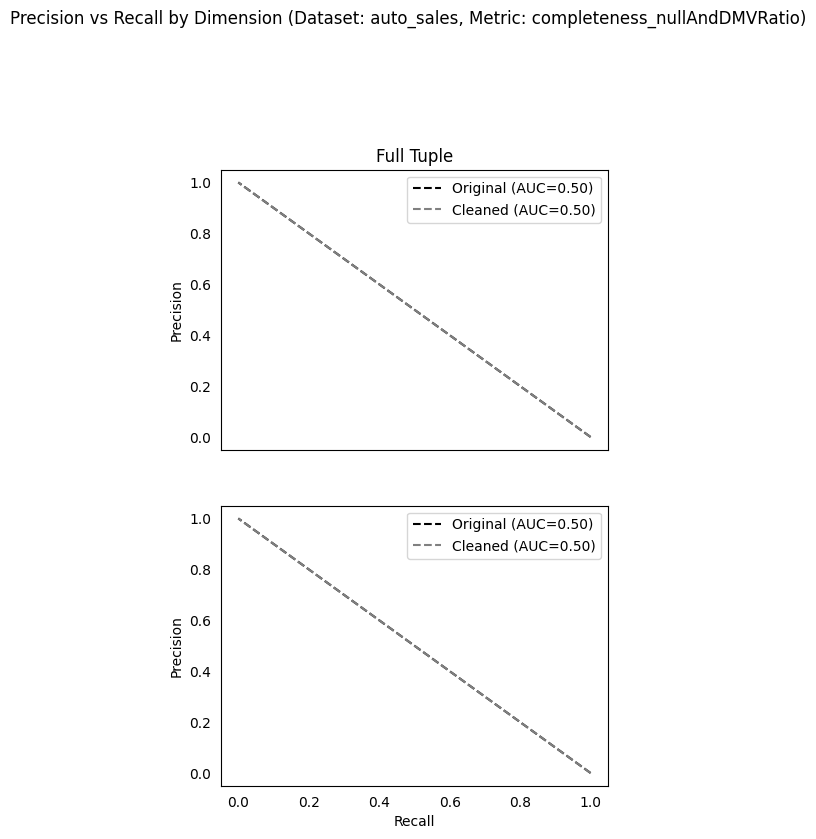

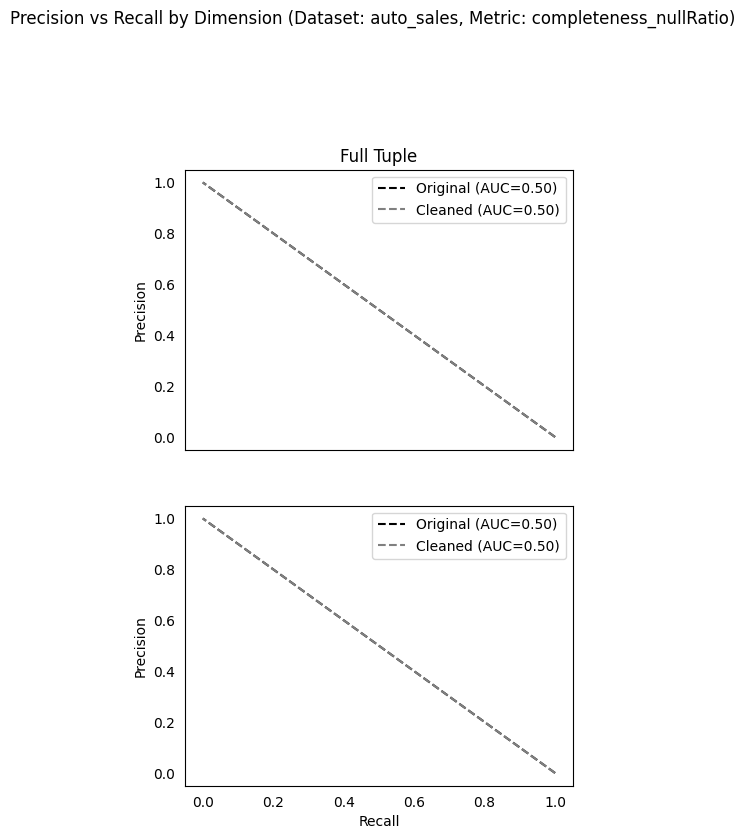

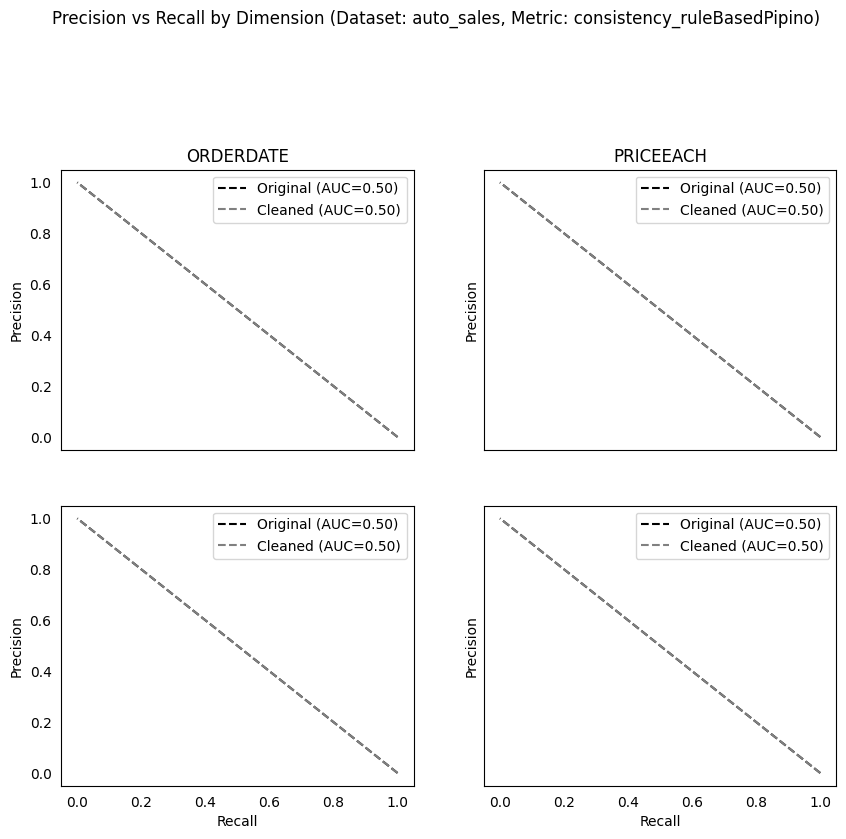

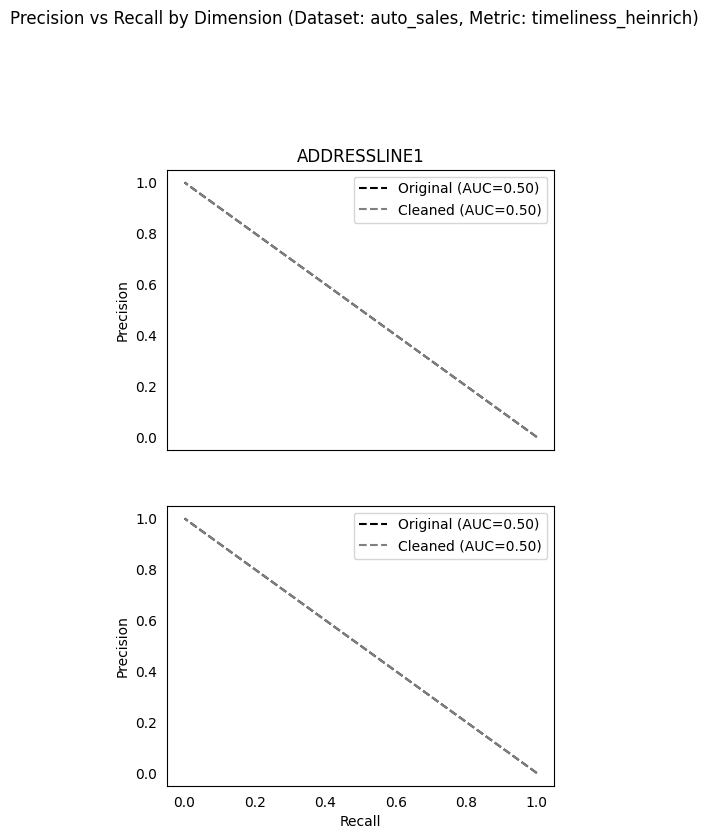

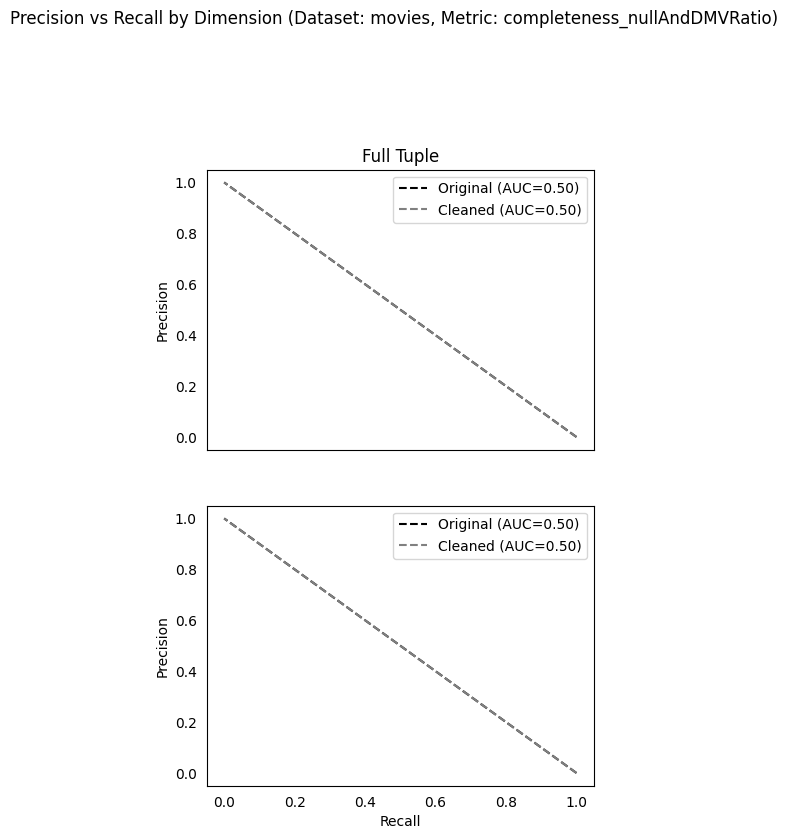

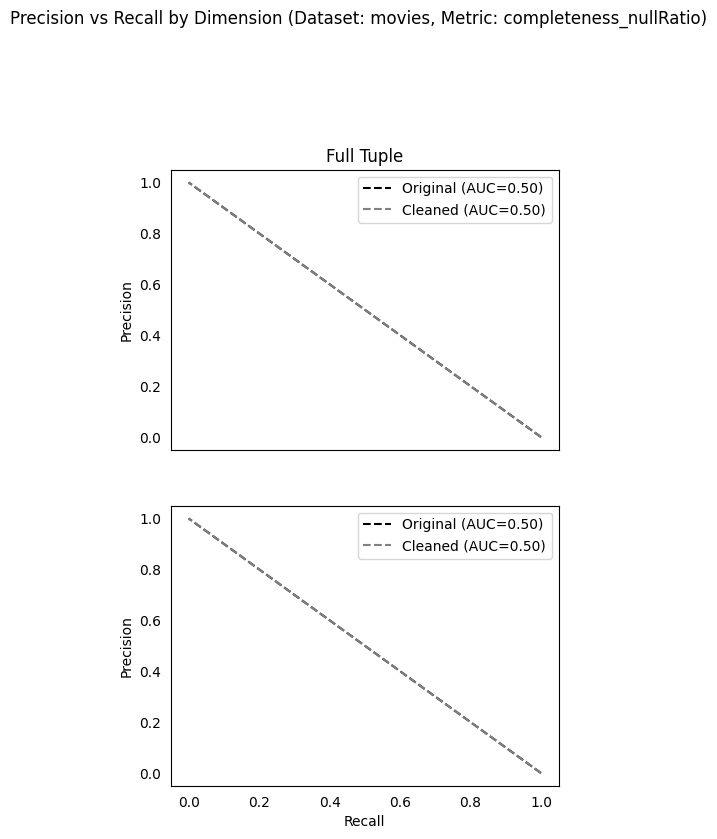

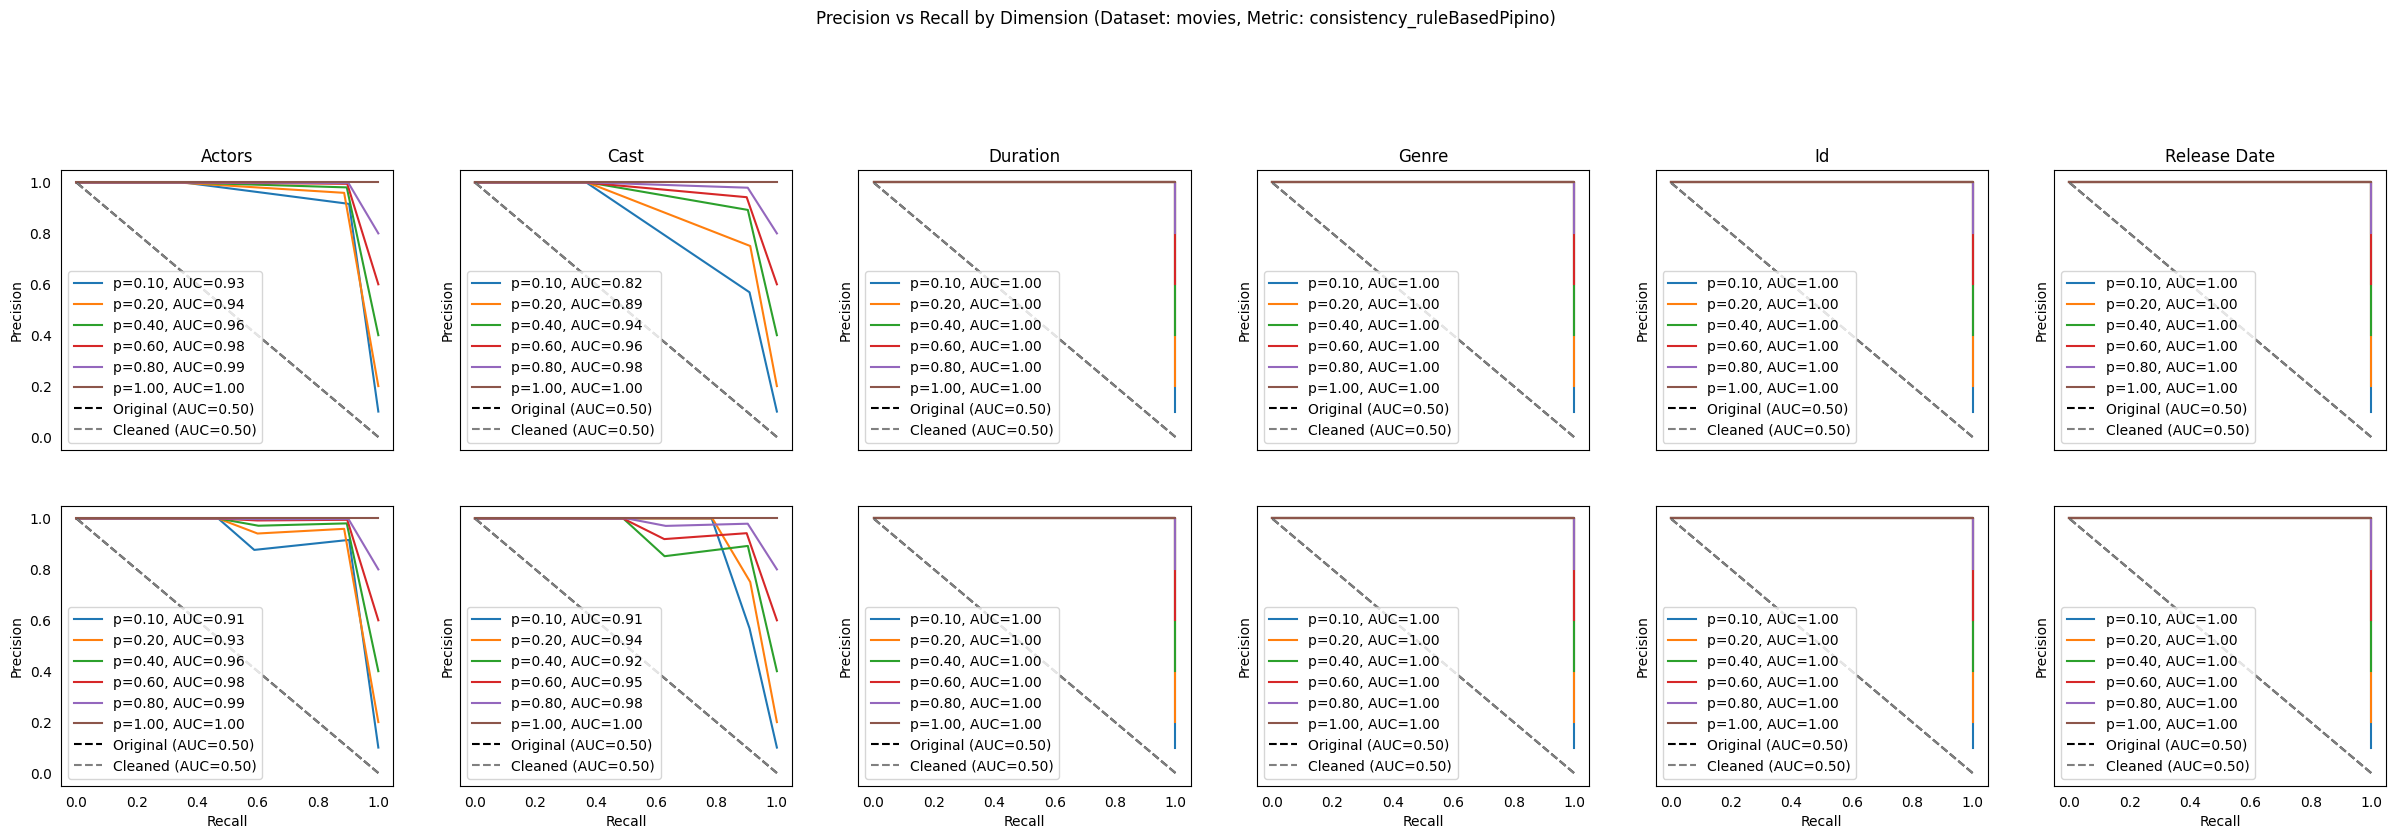

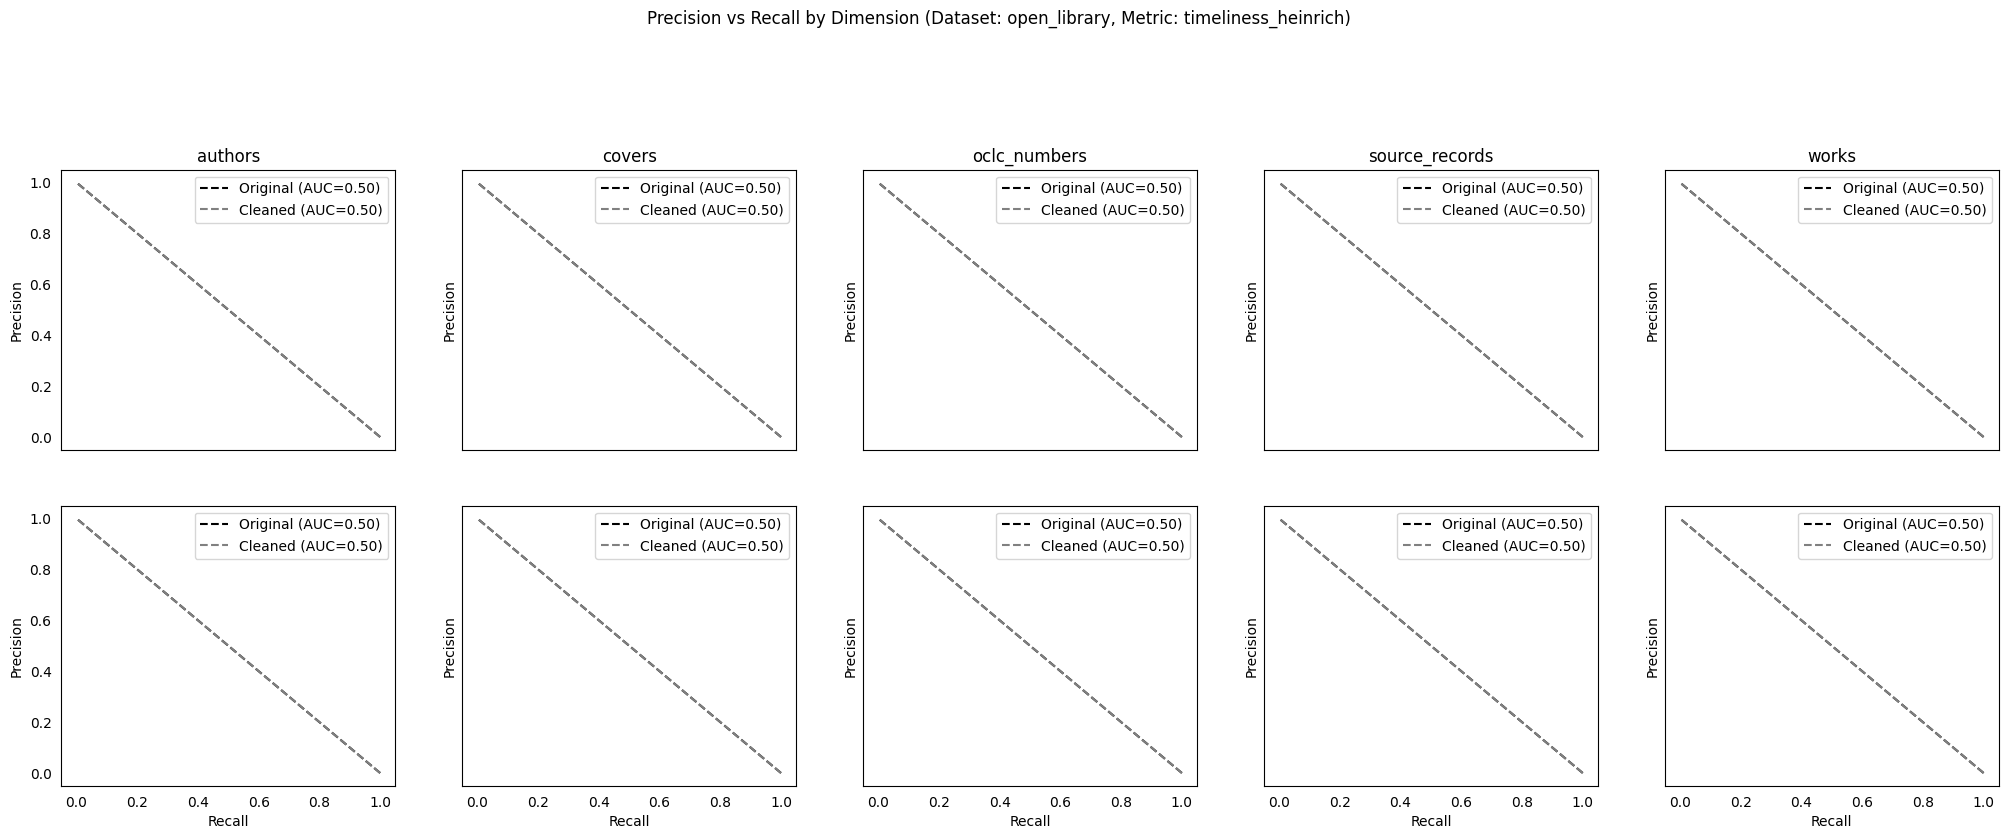

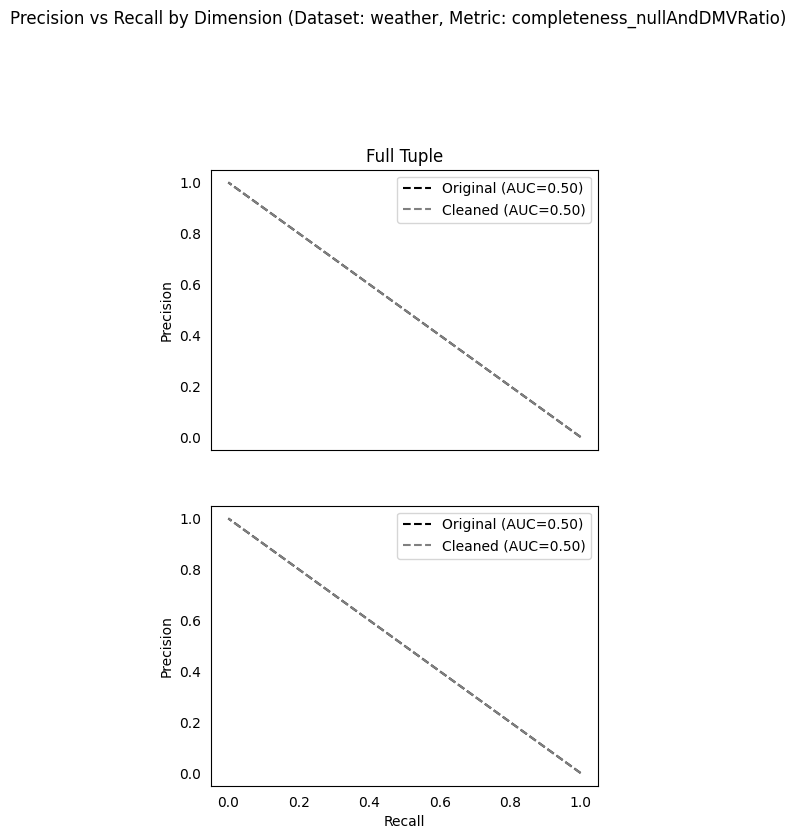

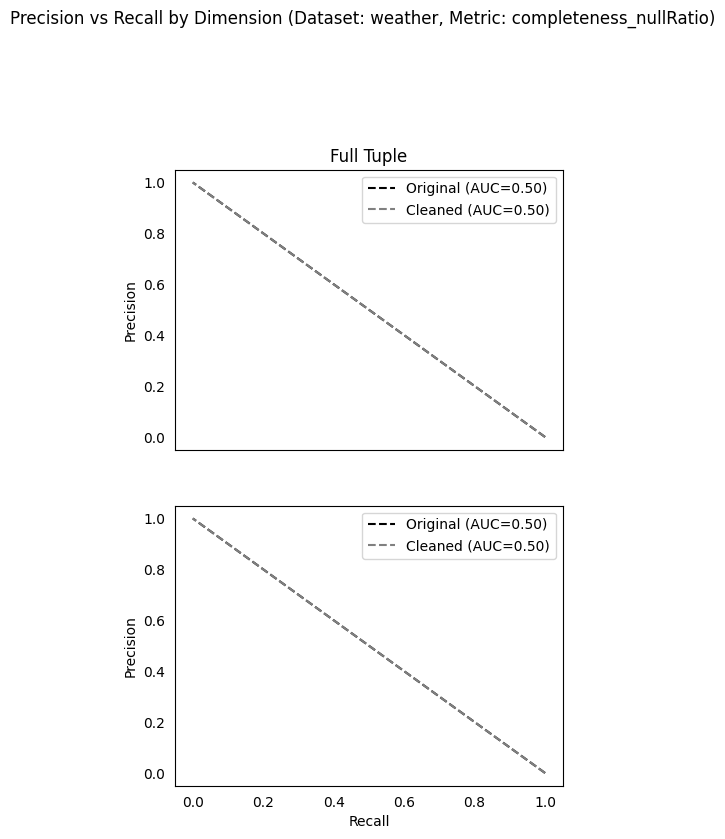

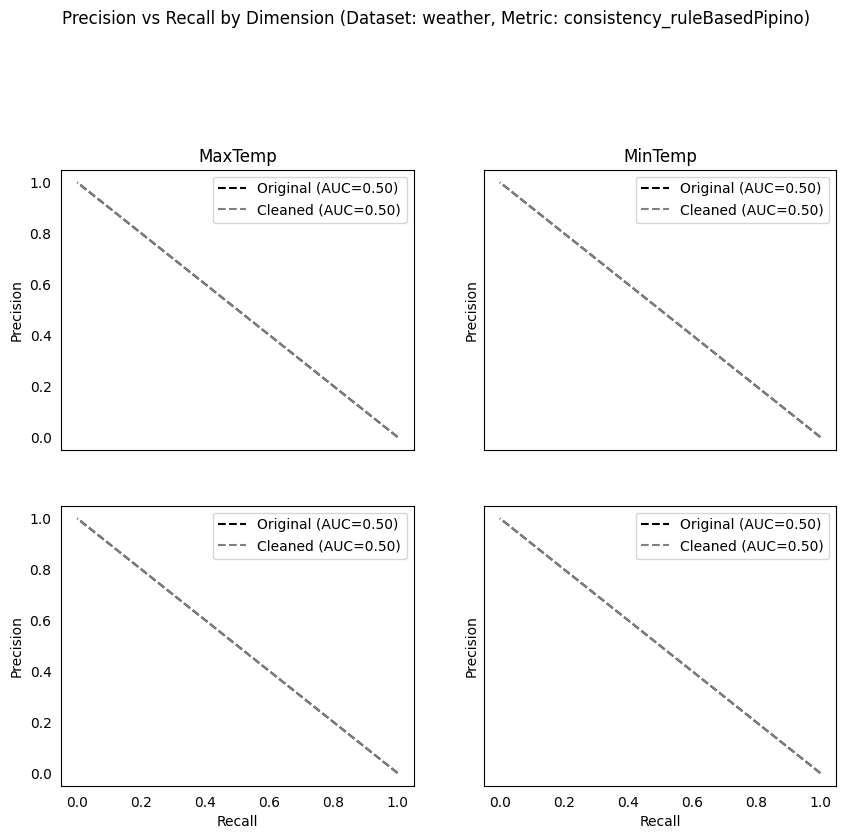

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


groups = df.groupby(["dataset", "metric"])

for (dataset, metric), data in groups:
    grouped_by_column = data.groupby("column")
    ncols = len(grouped_by_column)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=ncols,
        figsize=(5 * ncols, 4 * 2),
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(2, ncols)
    for (col_name, col_data), (col, _) in zip(grouped_by_column, enumerate(axes[0])):
        polluted_col_data = col_data[col_data["type"] == "polluted"]
        cleaned_col_data = col_data[col_data["type"] == "cleaned"]
        original_col_data = col_data[col_data["type"] == "original"]
        assert len(original_col_data) == 1, (
            col_name,
            dataset,
            metric,
            original_col_data,
        )
        assert len(cleaned_col_data) == 1, (col_name, dataset, metric, cleaned_col_data)

        ax1 = axes[0][col]
        ax2 = axes[1][col]
        ax1.set_ylabel("Precision")
        ax2.set_ylabel("Precision")
        ax1.set_title(str(col_name)[:20])
        for p_rate in polluted_col_data["pollution_rate"].index:
            ax1.plot(
                polluted_col_data.loc[p_rate]["recall"],
                polluted_col_data.loc[p_rate]["precision"],
                label=f"p={polluted_col_data.loc[p_rate]['pollution_rate']:.2f}, AUC={polluted_col_data.loc[p_rate]['pr_auc']:.2f}",
            )
            ax2.plot(
                polluted_col_data.loc[p_rate]["recall_weighted"],
                polluted_col_data.loc[p_rate]["precision_weighted"],
                label=f"p={polluted_col_data.loc[p_rate]['pollution_rate']:.2f}, AUC={polluted_col_data.loc[p_rate]['pr_auc_weighted']:.2f}",
            )
        ax1.plot(
            original_col_data["recall"].iloc[0],
            original_col_data["precision"].iloc[0],
            label="Original (AUC={:.2f})".format(original_col_data["pr_auc"].values[0]),
            color="black",
            linestyle="--",
        )
        ax1.plot(
            cleaned_col_data["recall"].iloc[0],
            cleaned_col_data["precision"].iloc[0],
            label="Cleaned (AUC={:.2f})".format(cleaned_col_data["pr_auc"].values[0]),
            color="gray",
            linestyle="--",
        )
        ax2.plot(
            original_col_data["recall_weighted"].iloc[0],
            original_col_data["precision_weighted"].iloc[0],
            label="Original (AUC={:.2f})".format(
                original_col_data["pr_auc_weighted"].values[0]
            ),
            color="black",
            linestyle="--",
        )
        ax2.plot(
            cleaned_col_data["recall_weighted"].iloc[0],
            cleaned_col_data["precision_weighted"].iloc[0],
            label="Cleaned (AUC={:.2f})".format(
                cleaned_col_data["pr_auc_weighted"].values[0]
            ),
            color="gray",
            linestyle="--",
        )
        ax1.legend()
        ax1.tick_params(axis="both", which="both", bottom=False, left=False)
        ax2.legend()
        ax2.tick_params(axis="both", which="both", bottom=False, left=False)
        ax2.set_xlabel("Recall")
    fig.suptitle(
        "Precision vs Recall by Dimension (Dataset: {}, Metric: {})".format(
            dataset, metric
        ),
        y=1.08,
    )
plt.show()

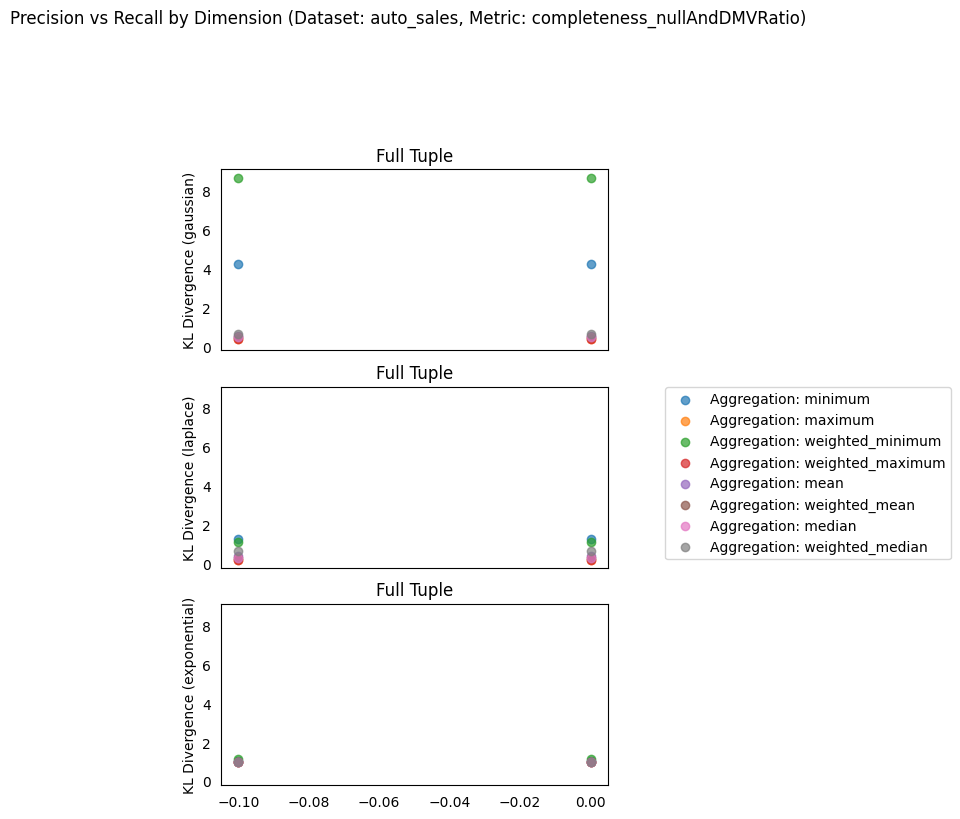

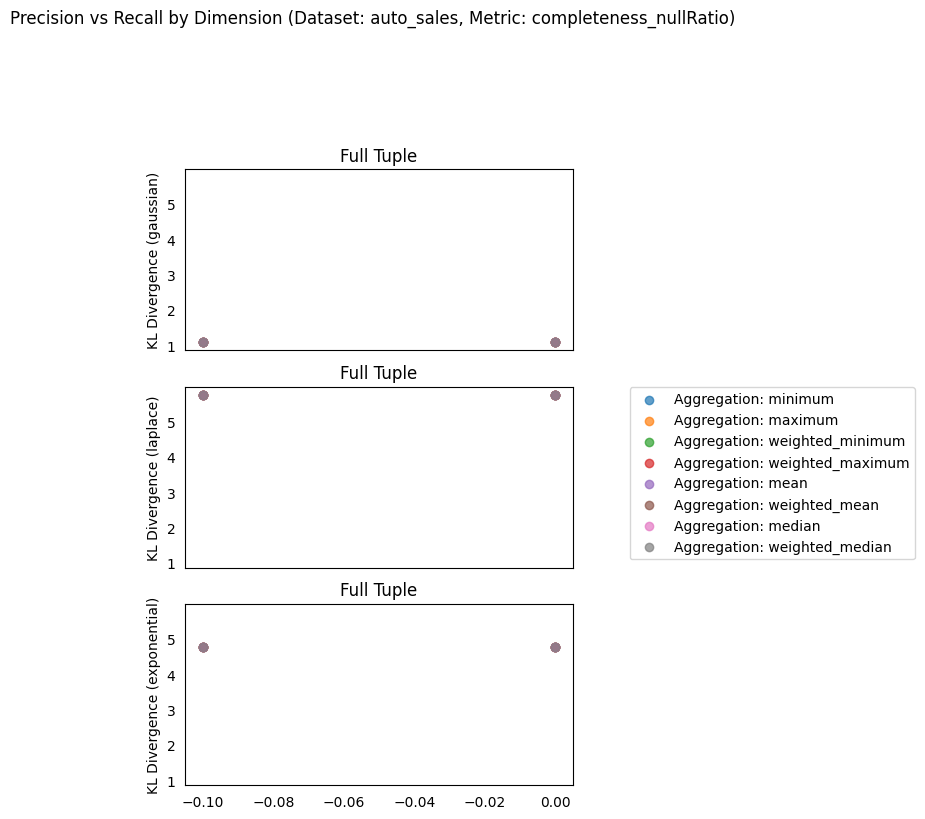

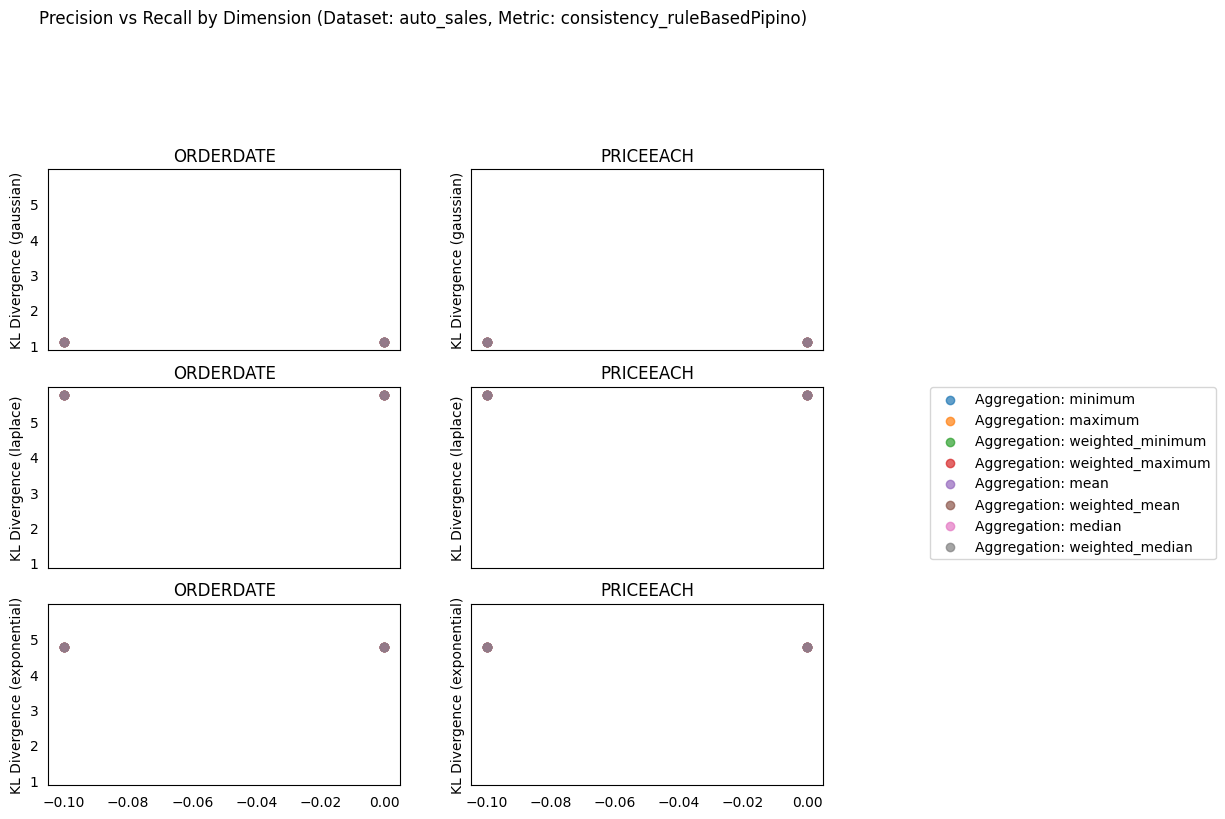

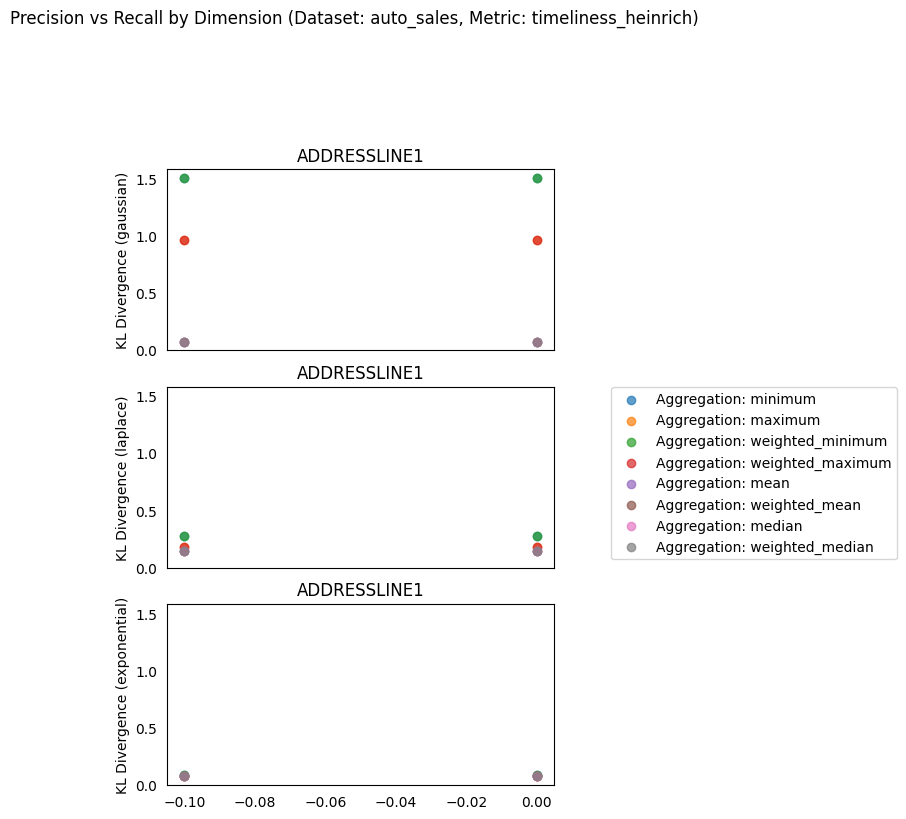

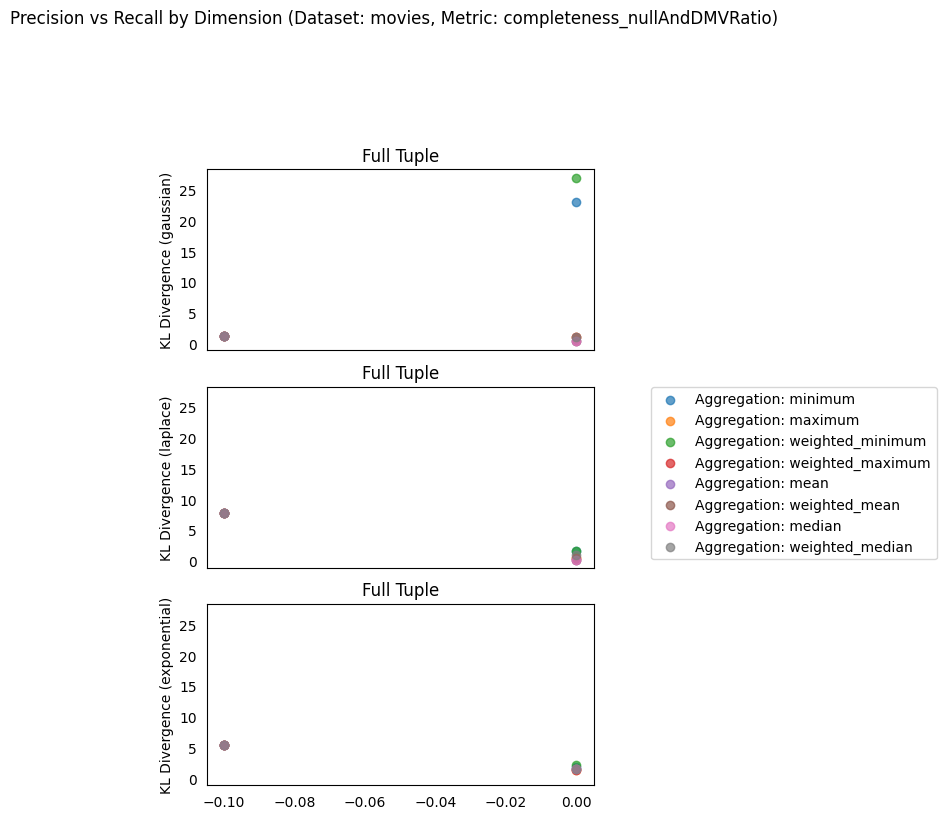

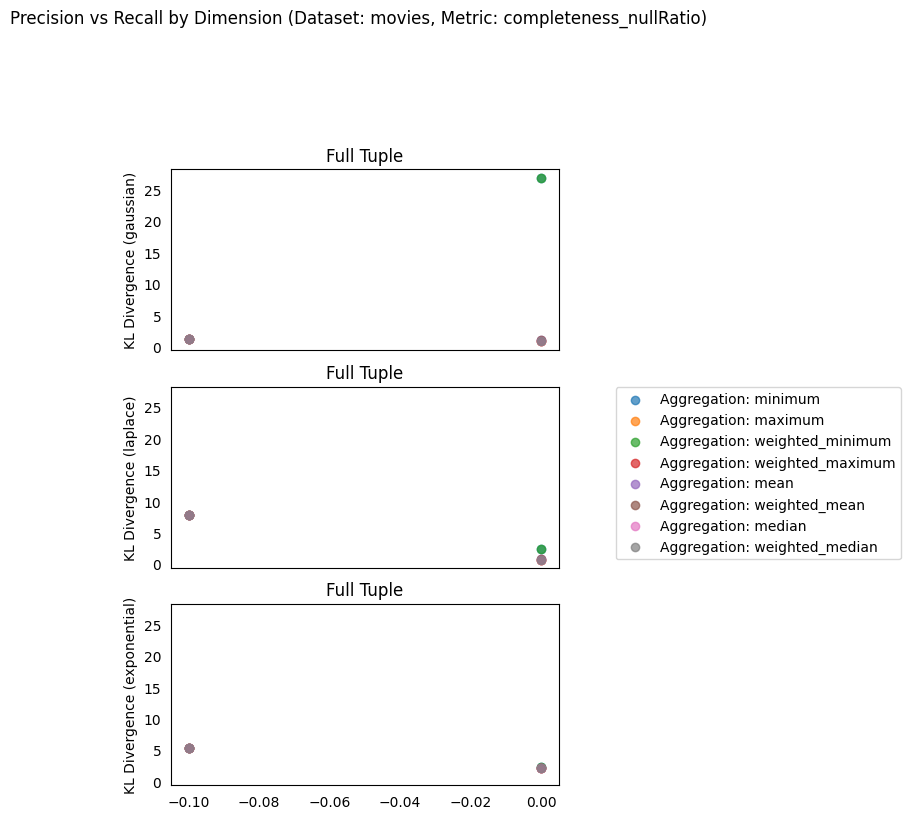

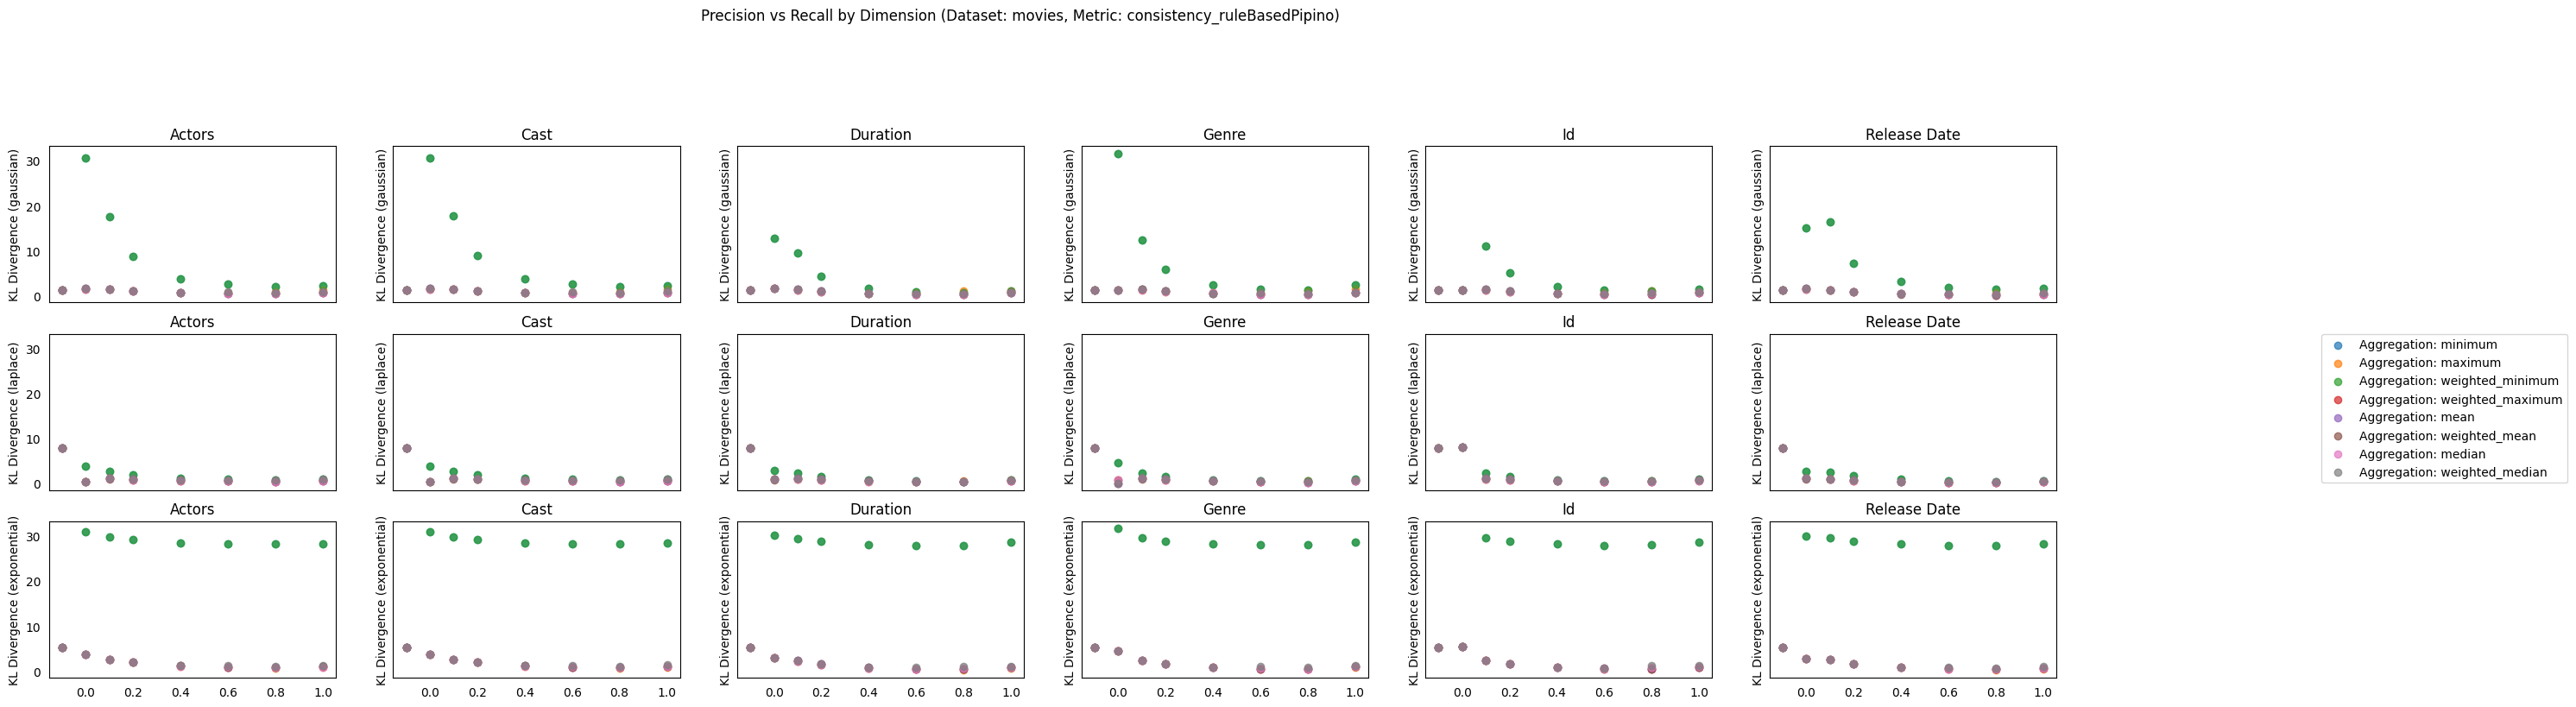

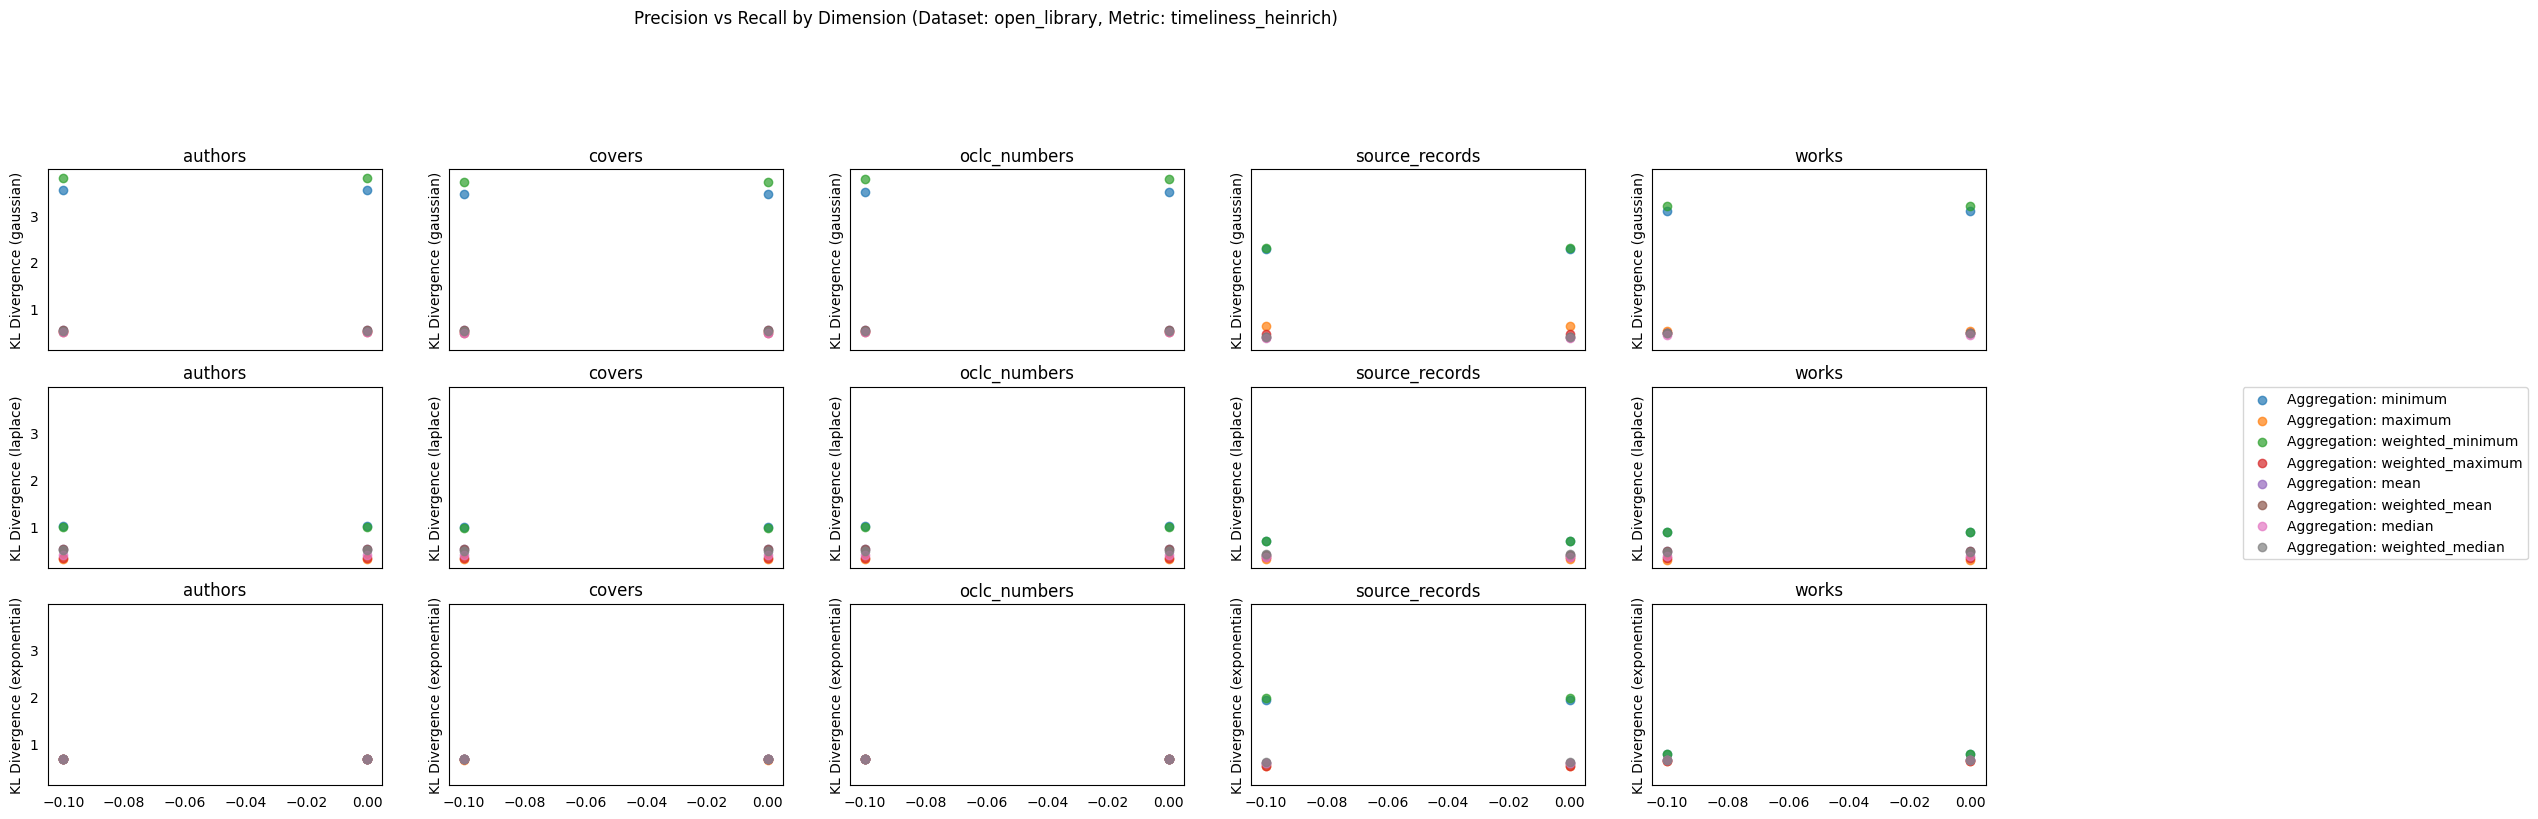

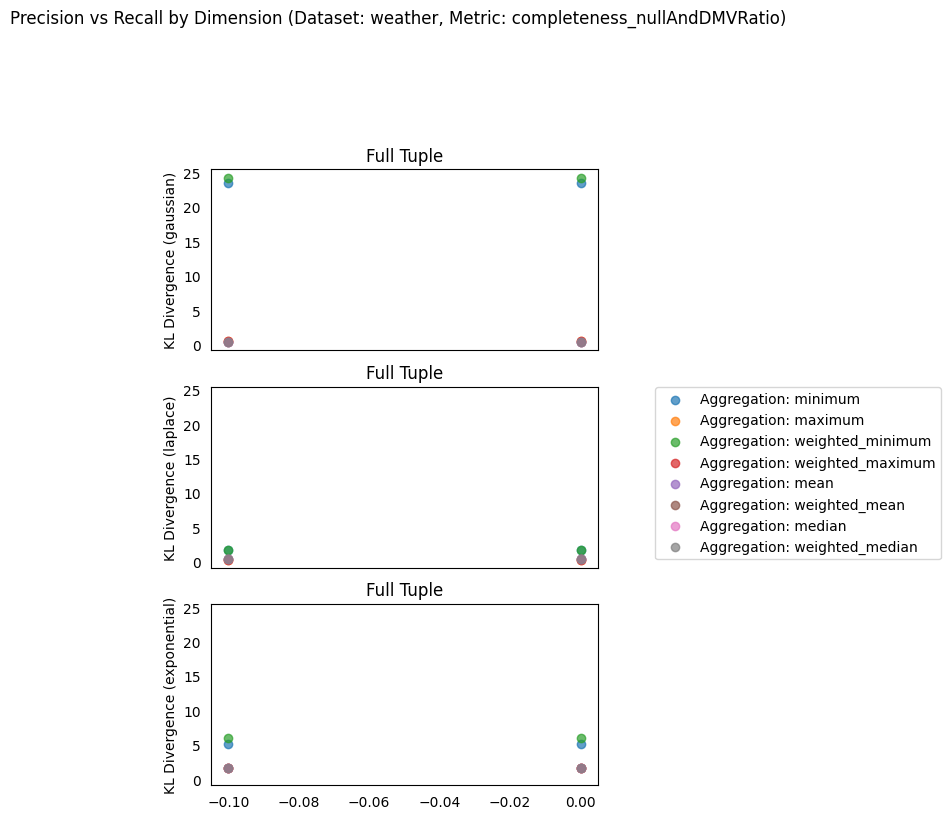

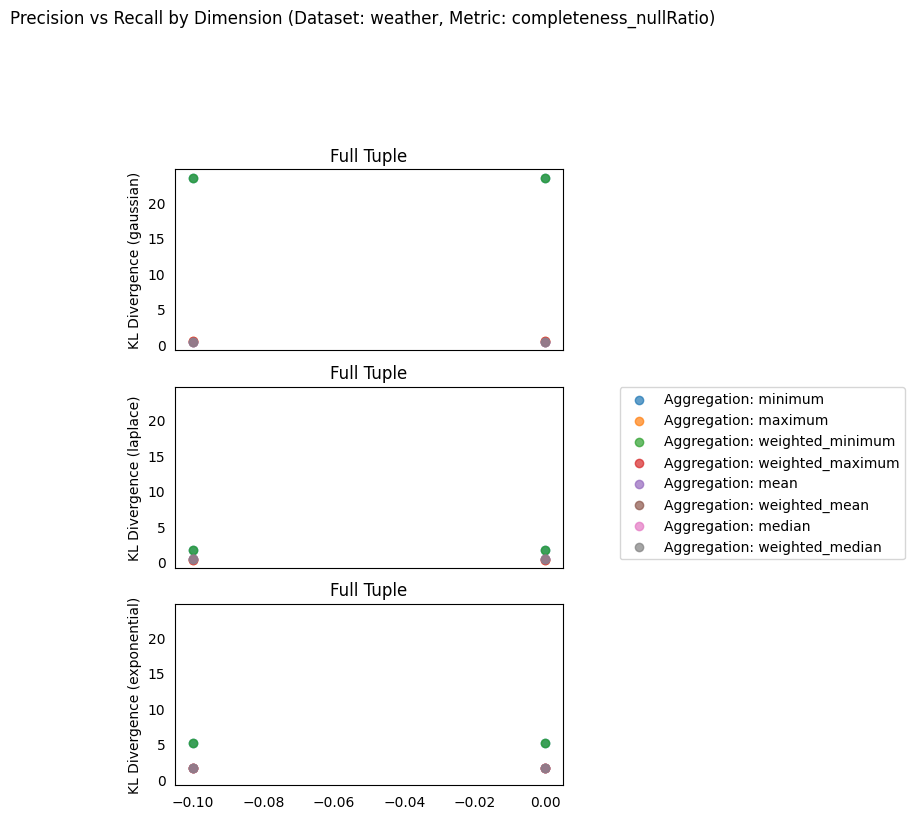

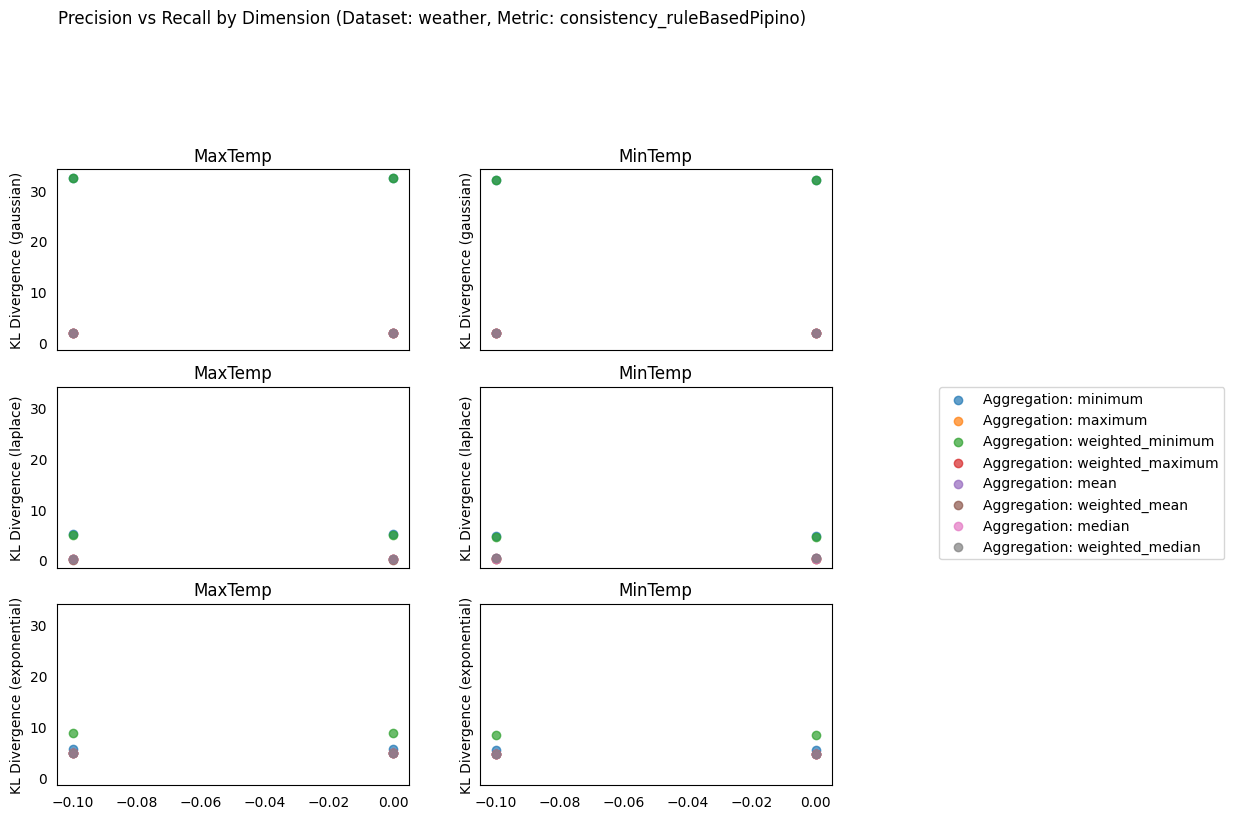

In [16]:
import matplotlib.pyplot as plt
import numpy as np

groups = df.groupby(["dataset", "metric"])

for (dataset, metric), data in groups:
    grouped_by_column = data.groupby("column")
    ncols = len(grouped_by_column)
    nrows = 3

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 4 * 2),
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(nrows, ncols)
    for (col_name, col_data), (col, _) in zip(grouped_by_column, enumerate(axes[0])):
        polluted_col_data = col_data[col_data["type"] == "polluted"]
        cleaned_col_data = col_data[col_data["type"] == "cleaned"]
        original_col_data = col_data[col_data["type"] == "original"]
        assert len(original_col_data) == 1, (
            col_name,
            dataset,
            metric,
            original_col_data,
        )
        assert len(cleaned_col_data) == 1, (col_name, dataset, metric, cleaned_col_data)

        p_rates = polluted_col_data["pollution_rate"]
        agg_methods = original_col_data.iloc[0]["kl_divergence"].keys()
        for ax, rec_model in zip(axes[:, col], ["gaussian", "laplace", "exponential"]):
            ax.set_ylabel(f"KL Divergence ({rec_model})")
            for agg_method in agg_methods:
                ax.scatter(
                    [-0.1, 0] + list(p_rates),
                    [
                        cleaned_col_data.iloc[0]["kl_divergence"][agg_method][
                            rec_model
                        ],
                        original_col_data.iloc[0]["kl_divergence"][agg_method][
                            rec_model
                        ],
                    ]
                    + list(
                        polluted_col_data["kl_divergence"].apply(
                            lambda x: x[agg_method][rec_model]
                        )
                    ),
                    label=f"Aggregation: {agg_method}",
                    alpha=0.7,
                    marker="o",
                )
                ax.set_title(str(col_name)[:20])
                ax.tick_params(axis="both", which="both", bottom=False, left=False)
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))
    fig.suptitle(
        "Precision vs Recall by Dimension (Dataset: {}, Metric: {})".format(
            dataset, metric
        ),
        y=1.08,
    )
plt.show()

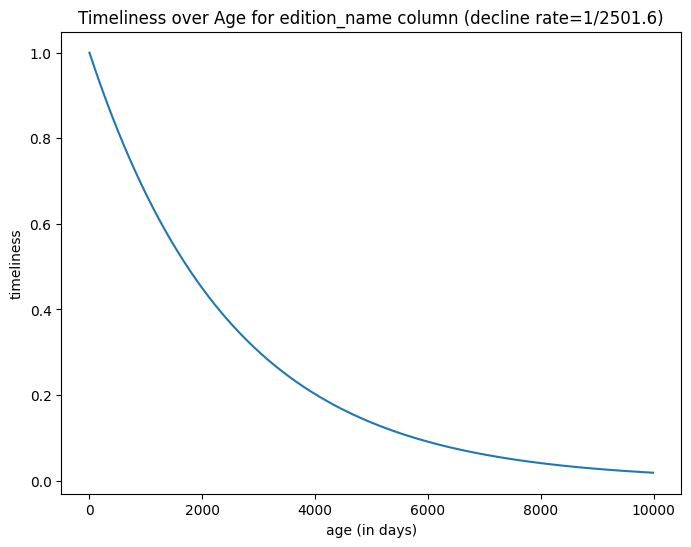

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def timeliness(decline, age):
    return np.exp(-decline * age)


# Make data
decline = 1 / 2501.6
x = np.arange(0, 10000, 10)
Z = timeliness(decline, x)
# Plot the timeliness graph
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, Z)
ax.set_xlabel("age (in days)")
ax.set_ylabel("timeliness")
ax.set_title("Timeliness over Age for edition_name column (decline rate=1/2501.6)")

plt.show()

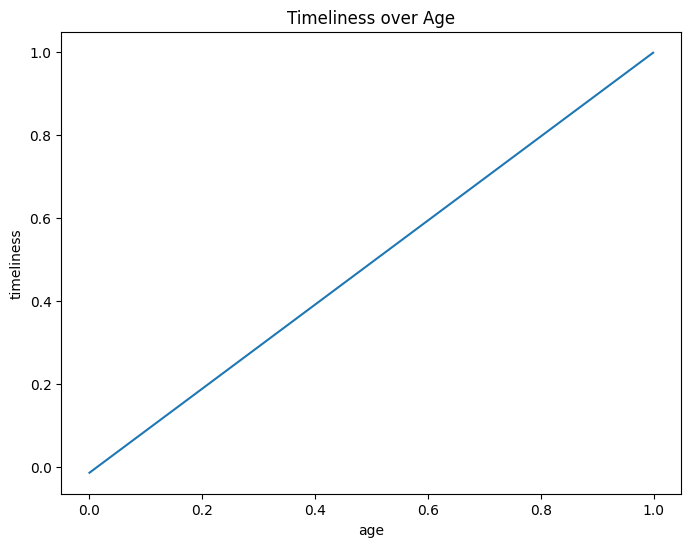

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def f(x):
    return (x - 0.4292**5) / (1 - 0.4292**5)


# Make data
x = np.arange(0, 1, 0.001)
Z = f(x)
# Plot the timeliness graph
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, Z)
ax.set_xlabel("age")
ax.set_ylabel("timeliness")
ax.set_title("Timeliness over Age")

plt.show()

In [4]:
import pandas as pd

df1 = pd.DataFrame([{"a": 1}, {"b": 2}])

df2 = pd.DataFrame([{"c": 3}, {"d": 4}])

df1.to_csv(
    "test.csv",
    mode="w",  # Write first, append rest
    header=True,  # Write header only for first chunk
    index=False,
)

df2.to_csv(
    "test.csv",
    mode="a",  # Write first, append rest
    header=True,  # Write header only for first chunk
    index=False,
)

Subset size: 0.009878213802435724
∆λ: 0.04631405022334961
∆θ: 0.17217229011668728


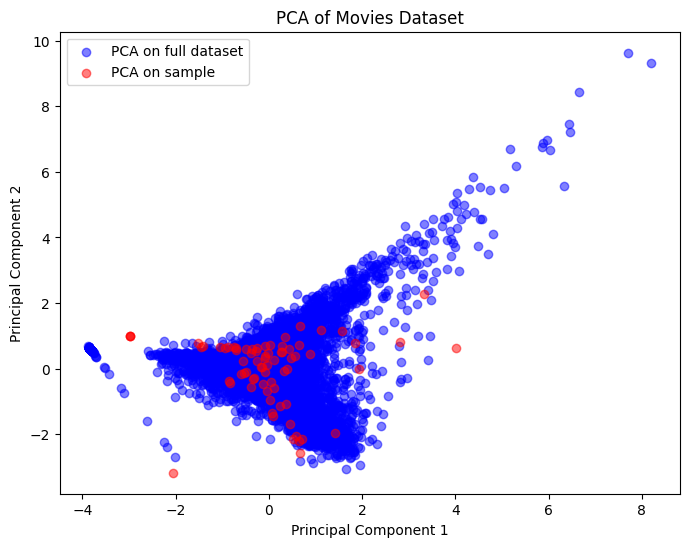

Subset size: 0.1
∆λ: 0.008130820111917458
∆θ: 0.13719394475256502


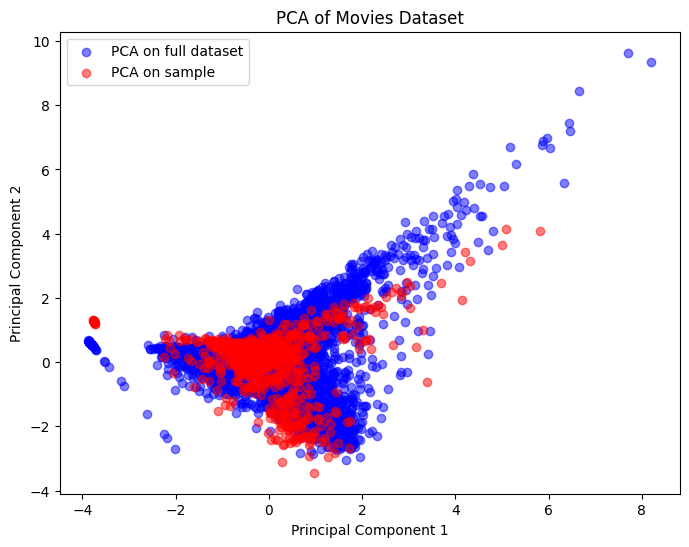

Subset size: 0.5
∆λ: 0.0008642617973823041
∆θ: 0.022737062165955214


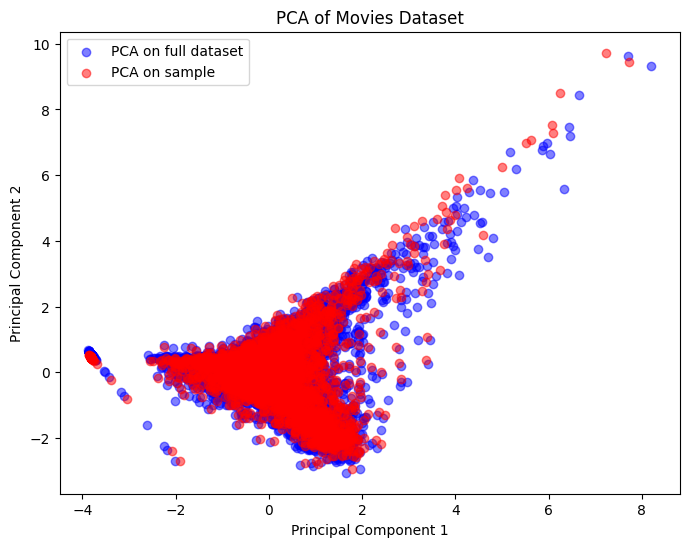

Subset size: 0.2553450608930988
∆λ: 0.2262445779185039
∆θ: 0.16023803594676733


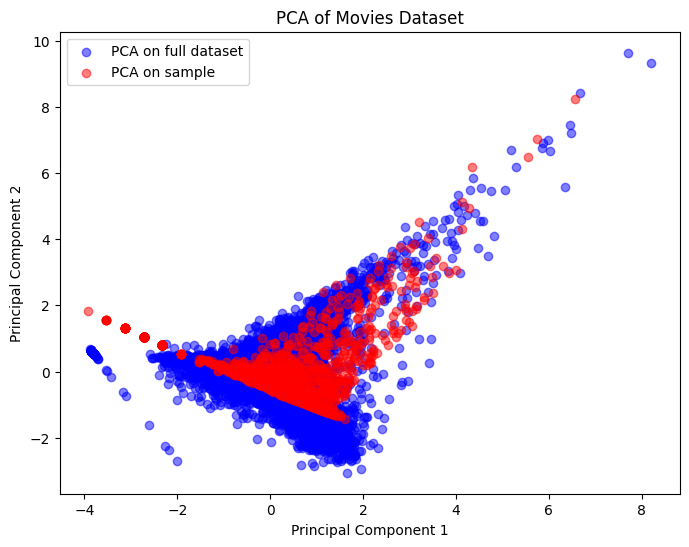

In [8]:
import pandas as pd
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

data = pd.read_csv(
    "/Users/jberndt/Documents/Masterarbeit/data-pollution/data/clean/movies.csv"
)
encoder = OrdinalEncoder(encoded_missing_value=-1).fit(
    data.select_dtypes(exclude=["object", "number"])
)
vectorizer = TfidfVectorizer()
concatenated_strings = (
    data.select_dtypes(include=["object"]).fillna("").agg(" ".join, axis=1)
)
X = encoder.transform(data.select_dtypes(exclude=["object", "number"]))
X = np.hstack((data.select_dtypes(include=["number"]).fillna(-1).to_numpy(), X))
# vectorizer.fit(concatenated_strings)
# S_X = vectorizer.transform(concatenated_strings)
# X = np.hstack((X, S_X.toarray()))
scaler = StandardScaler()
X = scaler.fit_transform(X)
n_features = X.shape[1]
n_components = 2
X_pca = PCA(n_components=n_components)
X_pca.fit(X)

X_reduced = X_pca.transform(X)

for idx in [
    np.random.choice(data.index, size=data.shape[0] // 100, replace=False),
    np.random.choice(data.index, size=data.shape[0] // 10, replace=False),
    np.random.choice(data.index, size=data.shape[0] // 2, replace=False),
    data[(data["Year"] > 2010)].index,
]:
    print("Subset size:", idx.size / data.shape[0])

    Y = X[idx]
    Y = scaler.fit_transform(Y)

    Y_pca = PCA(n_components=n_components)
    Y_pca.fit(Y)

    print(
        "∆λ:",
        n_features
        / (n_features + n_components - 2)
        * np.sum(
            np.abs(X_pca.explained_variance_ratio_ - Y_pca.explained_variance_ratio_)
        ),
    )
    print(
        "∆θ:",
        2
        / np.pi
        * min(
            np.arccos(
                np.clip(np.dot(X_pca.components_[0], Y_pca.components_[0]), -1.0, 1.0)
            ),
            np.arccos(
                np.clip(np.dot(X_pca.components_[0], -Y_pca.components_[0]), -1.0, 1.0)
            ),
        ),
    )

    Y_reduced = Y_pca.transform(Y)
    fig = plt.figure(figsize=(8, 6))
    plt.scatter(
        X_reduced[:, 0],
        X_reduced[:, 1],
        c="blue",
        label="PCA on full dataset",
        alpha=0.5,
    )
    plt.scatter(
        Y_reduced[:, 0],
        Y_reduced[:, 1],
        c="red",
        label="PCA on sample",
        alpha=0.5,
    )
    plt.legend()
    plt.title("PCA of Movies Dataset")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

In [ ]:
# Timeliness

from datetime import datetime
import pandas as pd
import numpy as np


original_data = pd.DataFrame(
    [
        {
            "edition_name": "First edition",
            "title": "The Scout's Outdoor Cookbook",
            "revision": 11,
            "last_modified": "2024-01-19T05:15:17.185339",
        },
        {
            "edition_name": "First edition",
            "title": "Road Bike Maintenance",
            "revision": 13,
            "last_modified": "2023-01-14T23:00:26.172383",
        },
        {
            "edition_name": "7th edition",
            "title": "Orland Florida Metro Area Street Atlas",
            "revision": 3,
            "last_modified": "2025-12-02T22:55:29.961812",
        },
    ]
)

polluted_data = pd.DataFrame(
    [
        {
            "edition_name": "First edition",
            "title": "Outdoor Cookbook",
            "revision": 10,
            "last_modified": "2023-11-10T15:50:01.245902",
        },
        {
            "edition_name": "First edition",
            "title": "Road Bike Maintenance",
            "revision": 13,
            "last_modified": "2023-01-14T23:00:26.172383",
        },
        {
            "edition_name": "7. edition",
            "title": "Orland Florida Street Atlas",
            "revision": 2,
            "last_modified": "2025-11-27T10:35:36.923053",
        },
    ]
)
assessment_date = datetime.fromisoformat("2026-01-19T12:00:00.000000")
ages = assessment_date - pd.to_datetime(polluted_data["last_modified"])
ages_in_days = ages.dt.total_seconds() / (3600 * 24)
decline_rates = np.array([[2501.6, 4760.34, 1147.03, 1147.03]] * len(polluted_data))
qualities = np.exp(
    -1
    / decline_rates
    * np.repeat(ages_in_days.to_numpy().reshape(-1, 1), len(decline_rates[0]), axis=1)
)

print(
    """
| age       | $q\\_time_{edition\\_name}$ | $q\\_time_{title}$ | $q\\_time_{revision}$ | $q\\_time_{last\\_modified}$ |
| --------- | ------------------------- | ----------------- | -------------------- | -------------------------- |
| $800.84$  | $0.$                  | $0.8452$          | $0.4972$             | $0.4972$                   |
| $1100.54$ | $0.6441$                  | $0.7936$          | $0.3828$             | $0.3828$                   |
| $53.06$   | $0.9790$                  | $0.9889$          | $0.9548$             | $0.9548$                   |
"""
    + f""
)

<>:62: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:62: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
/var/folders/rw/xym_kq6n3l9_0qkvb5l3bd_w0000gn/T/ipykernel_45265/436227875.py:62: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  | age       | $q\_time_{edition\_name}$ | $q\_time_{title}$ | $q\_time_{revision}$ | $q\_time_{last\_modified}$ |


KeyboardInterrupt: 

In [18]:
# Completeness

import pandas as pd
import numpy as np

from metis.metric.completeness.completeness_nullAndDMVRate import (
    IS_VALID_MARKER,
    IS_NULL_MARKER,
    IS_DMV_MARKER,
)
from metis.utils.disguised_missing_values.fahes.fahes import (
    FAHES_PRECISION,
    FAHES_RECALL,
)

original_data = pd.DataFrame(
    [
        {
            "Location": "Albury",
            "MinTemp": 13.4,
            "MaxTemp": 22.9,
            "Rainfall": 0.6,
            "WindGustDir": "W",
        },
        {
            "Location": "Albury",
            "MinTemp": 7.4,
            "MaxTemp": 25.1,
            "Rainfall": 0,
            "WindGustDir": "WNW",
        },
        {
            "Location": "Albury",
            "MinTemp": 17.5,
            "MaxTemp": 32.3,
            "Rainfall": 1,
            "WindGustDir": "W",
        },
    ]
)

polluted_data = original_data.copy()
polluted_data.loc[0, "MinTemp"] = np.nan
polluted_data.loc[0, "Rainfall"] = -1
polluted_data.loc[0, "WindGustDir"] = "UNK"
polluted_data.loc[1, "Location"] = "Unknown"
polluted_data.loc[1, "Rainfall"] = np.nan
polluted_data.loc[2, "MinTemp"] = -999
polluted_data.loc[2, "MaxTemp"] = 999
polluted_data.loc[2, "WindGustDir"] = "NA"

dmvs = pd.DataFrame(
    [
        {"col": "Location", "dmv": "Unknown", "false_positive": False},
        {"col": "MinTemp", "dmv": -999, "false_positive": False},
        {"col": "MaxTemp", "dmv": 999, "false_positive": False},
        {"col": "Rainfall", "dmv": 1, "false_positive": True},
        {"col": "WindGustDir", "dmv": "NA", "false_positive": False},
        {"col": "WindGustDir", "dmv": "WNW", "false_positive": True},
    ]
)

marked_cells = pd.DataFrame(
    IS_VALID_MARKER, index=polluted_data.index, columns=polluted_data.columns
)
marked_cells[polluted_data.isna()] = IS_NULL_MARKER
if dmvs is not None:
    for _, dmv_row in dmvs.iterrows():
        col = dmv_row["col"]
        val = dmv_row["dmv"]
        marked_cells.loc[polluted_data[col] == val, col] = IS_DMV_MARKER

qualities = marked_cells.replace(
    {IS_VALID_MARKER: 1, IS_NULL_MARKER: 0, IS_DMV_MARKER: 0}
).mean(axis=1)
qualities.name = "Completeness"

# Formula: $c = 1-\frac{(1-p_F)*\frac{n_{dmv}}{n}+(1-r_F)*\frac{n_{unflagged}}{n}}{(1-p_F)+(1-r_F)}$
certainties = 1 - (
    (1 - FAHES_PRECISION) * (marked_cells == IS_DMV_MARKER).mean(axis=1)
    + (1 - FAHES_RECALL) * (marked_cells == IS_VALID_MARKER).mean(axis=1)
) / ((1 - FAHES_PRECISION) + (1 - FAHES_RECALL))

print(
    f"""
**Original Data**

{original_data.to_markdown(index=False)}

**Polluted Data**

{polluted_data.to_markdown(index=False)}


Metric: `completeness_nullAndDMVRate`
- detected DMVs by FAHES
{"\n".join([("    - " + row["col"] + ": " + (str(row["dmv"]) if not row["false_positive"] else ("=="+str(row["dmv"])+"=="))) for _, row in dmvs.iterrows()])}

{pd.concat([marked_cells.replace({IS_VALID_MARKER: "$1$", IS_NULL_MARKER: "$0_{null}$", IS_DMV_MARKER: "$0_{dmv}$"}), qualities], axis=1).to_markdown(index=False)}

{certainties.to_frame(name="Certainty").to_markdown(index=False)}
"""
)


**Original Data**

| Location   |   MinTemp |   MaxTemp |   Rainfall | WindGustDir   |
|:-----------|----------:|----------:|-----------:|:--------------|
| Albury     |      13.4 |      22.9 |        0.6 | W             |
| Albury     |       7.4 |      25.1 |        0   | WNW           |
| Albury     |      17.5 |      32.3 |        1   | W             |

**Polluted Data**

| Location   |   MinTemp |   MaxTemp |   Rainfall | WindGustDir   |
|:-----------|----------:|----------:|-----------:|:--------------|
| Albury     |     nan   |      22.9 |         -1 | UNK           |
| Unknown    |       7.4 |      25.1 |        nan | WNW           |
| Albury     |    -999   |     999   |          1 | NA            |


Metric: `completeness_nullAndDMVRate`
- detected DMVs by FAHES
    - Location: Unknown
    - MinTemp: -999
    - MaxTemp: 999
    - Rainfall: ==1==
    - WindGustDir: NA
    - WindGustDir: ==WNW==

| Location   | MinTemp    | MaxTemp   | Rainfall   | WindGustDir   |   Completen

In [ ]:
import pandas as pd
import json

data = pd.read_csv(
    "/Users/jberndt/Documents/Masterarbeit/data-pollution/data/polluted/20260127_224826/timeliness/polluted_open-library-b0.mask.csv"
)
print(json.dumps(data.mean().sort_values().to_dict(), indent=2))

{
  "subject_places": 0.0,
  "scan_on_demand": 0.0,
  "isbn_odd_length": 0.0,
  "create": 0.0,
  "type_key": 0.0,
  "isbn_invalid": 0.0,
  "key": 0.0,
  "purchase_url": 0.0,
  "subject_people": 0.0,
  "oclc": 0.0,
  "word_count": 0.0,
  "original_isbn": 0.0,
  "lc_classification": 0.0,
  "subject_times": 0.0,
  "volumes": 1.7419023315362708e-06,
  "subject_time": 3.4838046630725417e-06,
  "collections": 3.4838046630725417e-06,
  "url": 5.225706994608812e-06,
  "links": 5.225706994608812e-06,
  "providers": 6.967609326145083e-06,
  "oclc_number": 8.709511657681355e-06,
  "openlibrary": 1.3935218652290167e-05,
  "work_titles": 1.3935218652290167e-05,
  "location": 1.5677120983826438e-05,
  "subject_place": 1.741902331536271e-05,
  "coverimage": 1.9160925646898977e-05,
  "genres": 2.090282797843525e-05,
  "work_title": 2.264473030997152e-05,
  "author": 3.1354241967652876e-05,
  "scan_records": 3.483804663072542e-05,
  "full_title": 8.535321424527726e-05,
  "dewey_decimal_class": 0.000113